In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('processed/clean_data.csv', parse_dates=['event_time'])
print(f"✓ Loaded: {df.shape[0]:,} rows")

✓ Loaded: 10,995,075 rows


In [2]:
# Which categories have the best and worst conversion rates?
category_funnel = []

for cat in df['category_top'].unique():
    cdf = df[df['category_top'] == cat]
    viewers  = cdf[cdf['event_type'] == 'view']['user_id'].nunique()
    carters  = cdf[cdf['event_type'] == 'cart']['user_id'].nunique()
    buyers   = cdf[cdf['event_type'] == 'purchase']['user_id'].nunique()

    if viewers > 1000:  # ignore tiny categories
        category_funnel.append({
            'category'        : cat,
            'viewers'         : viewers,
            'buyers'          : buyers,
            'conversion_pct'  : round(buyers / viewers * 100, 2),
            'cart_abandon_pct': round((1 - buyers/carters) * 100, 2) if carters > 0 else 0
        })

cat_df = pd.DataFrame(category_funnel).sort_values('conversion_pct', ascending=False)
print(cat_df.to_string(index=False))

    category  viewers  buyers  conversion_pct  cart_abandon_pct
 electronics  1346589   72883            5.41             54.37
  appliances   477915   15786            3.30             56.38
    medicine     2168      68            3.14             56.13
     unknown  1197483   35801            2.99             51.62
   computers   217285    5389            2.48             54.23
  stationery     1388      34            2.45             47.69
construction    77251    1515            1.96             60.95
        auto   104056    2002            1.92             50.05
        kids    65338    1134            1.74             44.63
   furniture   150796    1808            1.20             51.06
 accessories    32935     372            1.13             48.04
       sport    23083     254            1.10             56.95
     apparel   209702    2039            0.97             55.52
country_yard     1976      10            0.51             72.22


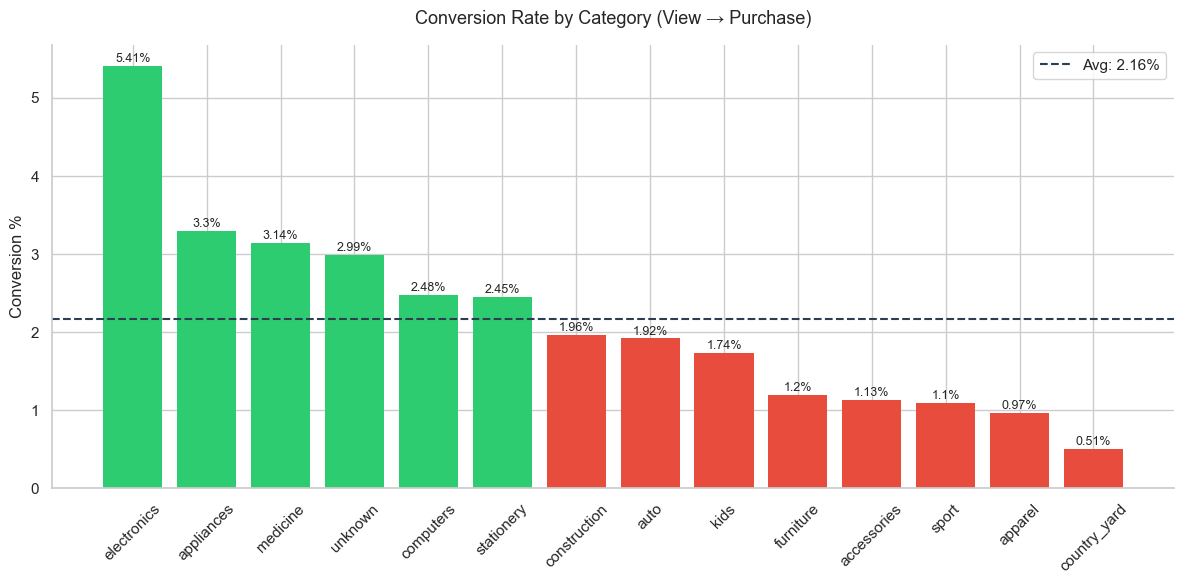

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ECC71' if x > cat_df['conversion_pct'].mean() 
          else '#E74C3C' for x in cat_df['conversion_pct']]

bars = ax.bar(cat_df['category'], cat_df['conversion_pct'], 
              color=colors, edgecolor='none')

# Average line
avg = cat_df['conversion_pct'].mean()
ax.axhline(avg, color='#2C3E50', linestyle='--', linewidth=1.5, label=f'Avg: {avg:.2f}%')

for bar, val in zip(bars, cat_df['conversion_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val}%', ha='center', fontsize=9)

ax.set_title('Conversion Rate by Category (View → Purchase)', fontsize=13, pad=15)
ax.set_ylabel('Conversion %')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('processed/04_category_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Only purchase events have meaningful revenue
purchases = df[df['event_type'] == 'purchase'].copy()

print("=== REVENUE OVERVIEW ===")
print(f"Total revenue:    ${purchases['price'].sum():,.2f}")
print(f"Avg order value:  ${purchases['price'].mean():,.2f}")
print(f"Median order:     ${purchases['price'].median():,.2f}")

# Revenue by category
rev_by_cat = purchases.groupby('category_top')['price'].agg(
    total_revenue='sum',
    avg_price='mean',
    total_orders='count'
).sort_values('total_revenue', ascending=False).round(2)

print("\n=== REVENUE BY CATEGORY ===")
print(rev_by_cat.to_string())

=== REVENUE OVERVIEW ===
Total revenue:    $50,575,694.55
Avg order value:  $304.90
Median order:     $174.30

=== REVENUE BY CATEGORY ===
              total_revenue  avg_price  total_orders
category_top                                        
electronics     38303018.05     417.60         91722
unknown          5279998.64     130.16         40565
appliances       3166492.59     182.77         17325
computers        2500535.53     403.51          6197
furniture         423308.12     213.36          1984
auto              267910.78     123.86          2163
construction      201582.23     123.75          1629
apparel           184544.63      81.77          2257
kids              148253.66     119.95          1236
sport              76837.52     277.39           277
accessories        17112.66      41.84           409
medicine            2975.83      43.76            68
country_yard        2477.69     247.77            10
stationery           646.62      17.96            36


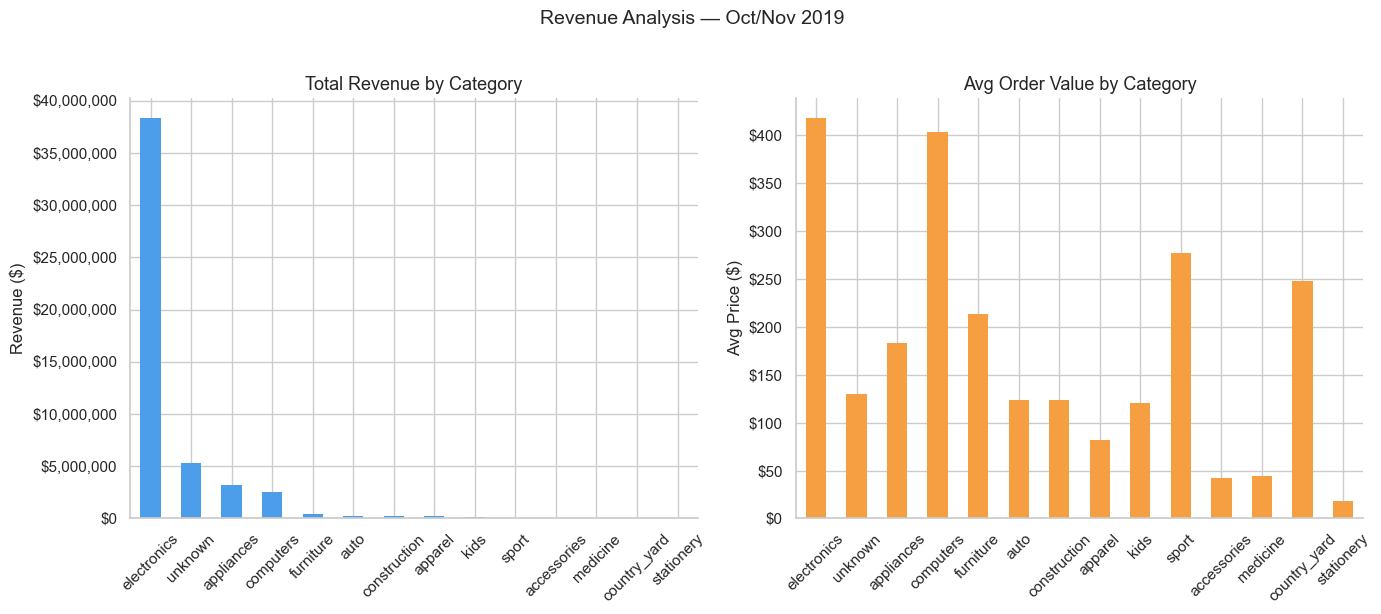

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Total revenue by category
rev_by_cat['total_revenue'].plot(kind='bar', ax=axes[0], 
                                  color='#4C9EEB', edgecolor='none')
axes[0].set_title('Total Revenue by Category', fontsize=13)
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2 — Avg order value by category
rev_by_cat['avg_price'].plot(kind='bar', ax=axes[1], 
                              color='#F59E42', edgecolor='none')
axes[1].set_title('Avg Order Value by Category', fontsize=13)
axes[1].set_ylabel('Avg Price ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Revenue Analysis — Oct/Nov 2019', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('processed/05_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

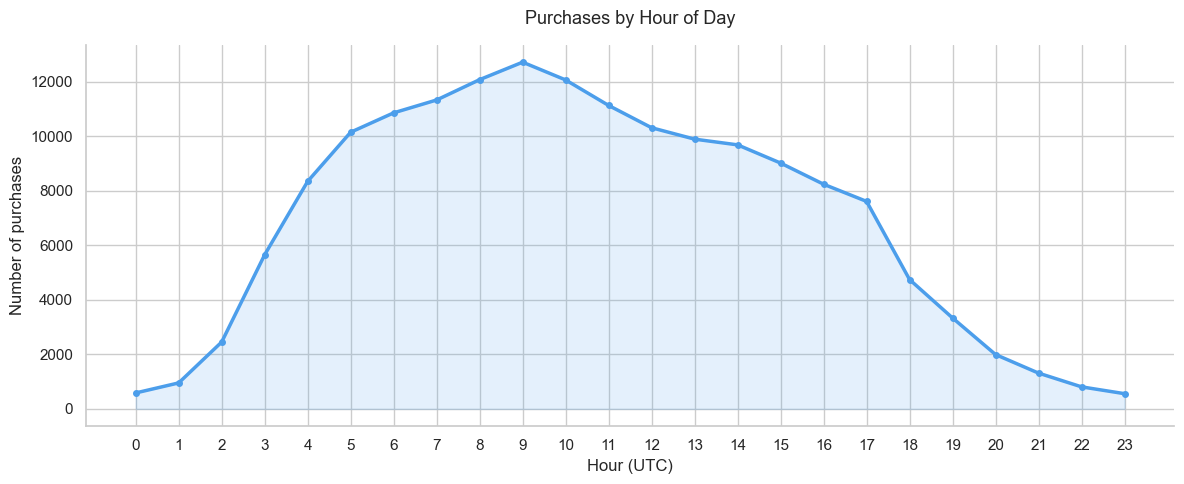

In [6]:
# What time of day do people buy most?
hourly = df[df['event_type'] == 'purchase'].groupby('hour')['user_id'].count()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly.values, color='#4C9EEB', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='#4C9EEB')

ax.set_title('Purchases by Hour of Day', fontsize=13, pad=15)
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Number of purchases')
ax.set_xticks(range(0, 24))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('processed/06_hourly_purchases.png', dpi=150, bbox_inches='tight')
plt.show()

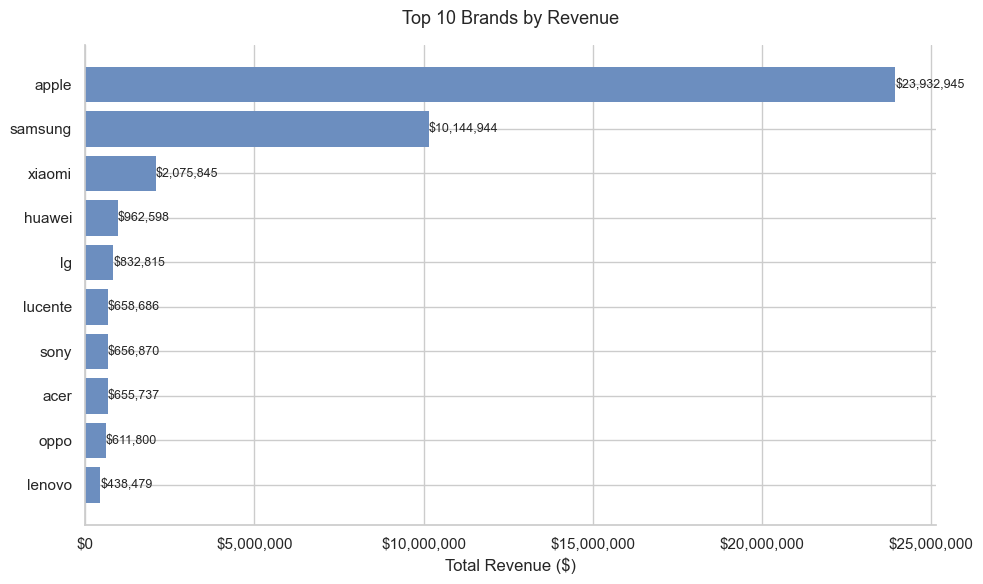

In [7]:
top_brands = (purchases[purchases['brand'] != 'unknown']
              .groupby('brand')['price']
              .agg(revenue='sum', orders='count')
              .sort_values('revenue', ascending=False)
              .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_brands.index[::-1], top_brands['revenue'][::-1], 
               color='#6C8EBF', edgecolor='none')

for bar, val in zip(bars, top_brands['revenue'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Brands by Revenue', fontsize=13, pad=15)
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('processed/07_top_brands.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# These are the clean export files Power BI will use

# 1. Full clean data
df.to_csv('processed/powerbi_main.csv', index=False)

# 2. Funnel summary
funnel_export = pd.DataFrame({
    'stage'           : ['View', 'Cart', 'Purchase'],
    'users'           : [2602816, 280392, 131195],
    'conv_from_view'  : [100.00, 10.77, 5.04],
    'step_conv'       : [100.00, 10.77, 46.79]
})
funnel_export.to_csv('processed/powerbi_funnel.csv', index=False)

# 3. Category funnel
cat_df.to_csv('processed/powerbi_category.csv', index=False)

# 4. Revenue by category
rev_by_cat.reset_index().to_csv('processed/powerbi_revenue.csv', index=False)

# 5. Monthly funnel
monthly = pd.DataFrame({
    'month'           : ['Oct 2019', 'Nov 2019'],
    'viewers'         : [1365004, 1784605],
    'carters'         : [72626, 218034],
    'buyers'          : [60458, 76691],
    'view_to_cart'    : [5.32, 12.22],
    'cart_to_purchase': [83.25, 35.17],
    'view_to_purchase': [4.43, 4.30]
})
monthly.to_csv('processed/powerbi_monthly.csv', index=False)

print("✓ All Power BI export files saved to processed/")
print("\nFiles ready:")
print("  - powerbi_main.csv")
print("  - powerbi_funnel.csv")
print("  - powerbi_category.csv")
print("  - powerbi_revenue.csv")
print("  - powerbi_monthly.csv")

✓ All Power BI export files saved to processed/

Files ready:
  - powerbi_main.csv
  - powerbi_funnel.csv
  - powerbi_category.csv
  - powerbi_revenue.csv
  - powerbi_monthly.csv
